# Lumerical 2D FDTD 验证：均匀布拉格光栅的禁带与带边慢光

**目的**：把 `lab-note.ipynb` 里用 CMT/TMM 得到的三个预言，放进第一性原理电磁仿真里独立检验——

1. 禁带中心在 $\lambda_B = 2\bar{n}\Lambda$，带宽 $\Delta\lambda \approx \lambda_B^2\kappa/(\pi n_g)$（强耦合极限 $2\kappa$ 的角频率宽度）；
2. 带**内**群延迟 $\tau \approx 0$（倏逝场，无净能流），带**边**出现群延迟峰（慢光，$n_g$ 增强）；
3. 无耗散介质中 $R + T = 1$ —— 被"抵消"的反射没有消失，能量只是被排出了。

**仿真器**：ANSYS Lumerical FDTD 2025 R2，**2D 有效折射率近似**（TE0 模压在面内，横向折射率分布用 $\bar n$ 的脊波导代替真实的 TFLN 薄膜模）。这是比 TMM 更"第一性"但仍然便宜的层次：所有 Maxwell 方程都在解，但维数从 3D 降到 2D。

**对应仿真文件**：`lumerical/run_bragg_2d.py`（构建 + 运行 + 提取，可重复）；数据：`lumerical/results/bragg2d.npz`。

## 0. 从 CMT 参数到 FDTD 几何的映射

设计遵循 lab-note 的均匀光栅仿真参数（$\kappa \approx 500\,\mathrm{cm^{-1}}$ 量级）：

| CMT 参数 | 值 | FDTD 几何实现 |
|---|---|---|
| 平均有效折射率 $\bar n$ | 2.02 | 脊波导折射率 |
| 折射率调制 $\Delta n$ | 0.02 | 方波折射率块 $\bar n \pm \Delta n$，半周期交替 |
| 周期 $\Lambda$ | 387.5 nm | $\lambda_B = 2\bar n\Lambda = 1565.5$ nm |
| 周期数 $N$ | 200（$L = 77.5\,\mu$m） | 400 个矩形块 |
| 耦合系数 $\kappa$ | $4\Delta n/\lambda_B \approx 511\,\mathrm{cm^{-1}}$ | 方波一阶傅里叶分量自动给出 |
| $\kappa L$ | 3.96（强反射区） | — |

**方波 → κ**：折射率方波 $n(z) = \bar n + \Delta n\,\mathrm{sq}(2\pi z/\Lambda)$ 的一阶傅里叶振幅是 $4\Delta n/\pi$，代入 CMT 重叠积分得 $\kappa = k_0 \cdot (4\Delta n/\pi)/2 = 4\Delta n/\lambda_B$。高阶谐波（$3\Lambda^{-1}$ 等）落在光频远离布拉格条件的频率，影响忽略。

其余设置：FDTD 区域 $6 \times 89\,\mu\mathrm{m}^2$，全程 PML；均匀网格 $dx=20$ nm、$dz=10$ nm（每周期约 39 格，远小于介质内波长/10 的收敛标准）；模式光源注入基模，脉冲覆盖 1520–1620 nm；透射功率监视器 + 同面复场监视器（121 个频点，用于相位→群延迟）。

**群延迟的提取**：对透过复场 $\tilde E(f)$ 取相位并 unwrap，$\tau = \frac{d\phi}{d\omega}$。光栅引起的**附加**群延迟 = 有光栅的 $\tau$ 减去同长度直波导参考仿真的 $\tau_{\rm ref}$。参考仿真同时给出波导真实的群折射率 $n_g = c\,\tau_{\rm ref}/L_{\rm path}$，用于解析曲线对比（自洽校准，不必手猜波导色散）。

In [1]:

import matplotlib
from matplotlib import font_manager
for _f in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if any(_f.lower() in f.name.lower() for f in font_manager.fontManager.ttflist):
        matplotlib.rcParams["font.family"] = _f
        break
matplotlib.rcParams["axes.unicode_minus"] = False

import numpy as np
import matplotlib.pyplot as plt

d = np.load(r"lumerical/results/bragg2d.npz")
f, wl = d["f"], d["wl"]
T, R = d["T"], d["R"]
tau_g, tau_ref = d["tau_g"], d["tau_ref"]
lam_B, kappa, L = d["lambda_B"], d["kappa"], d["L"]
dn, n_bar = d["dn"], d["n_bar"]

c = 299792458.0
L_path = L + 4e-6           # source -> through-monitor propagation length
n_g = c * np.mean(tau_ref) / L_path

order = np.argsort(wl)
wl_nm = wl[order] * 1e9

print(f"FDTD 提取的群折射率 n_g = {n_g:.3f}  (介质 n_bar = {n_bar})")
print(f"设计: lambda_B = {lam_B*1e9:.1f} nm, kappa = {kappa/100:.0f} /cm, kappa*L = {kappa*L:.2f}")

# --- 实测禁带：T = 0.5 的两个交点 -> 带宽直接反演 kappa_fit ---
T_o = T[order]; wl_o = wl[order]
ic = np.argmin(np.abs(wl_o - lam_B))
i1 = ic
while i1 > 0 and T_o[i1] < 0.5: i1 -= 1
i2 = ic
while i2 < len(T_o) - 1 and T_o[i2] < 0.5: i2 += 1
def _cross(i):
    x0, x1 = wl_o[i], wl_o[i+1]; y0, y1 = T_o[i], T_o[i+1]
    return x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)
wl_lo_e, wl_hi_e = _cross(i1), _cross(i2)
kappa_fit = (wl_hi_e - wl_lo_e) * np.pi * n_g / lam_B**2
print(f"禁带实测: {wl_lo_e*1e9:.2f} ~ {wl_hi_e*1e9:.2f} nm,  带宽 {(wl_hi_e-wl_lo_e)*1e9:.2f} nm")
print(f"kappa_fit = {kappa_fit/100:.0f} /cm  (设计值 {kappa/100:.0f}; 台阶网格略增强耦合)")
print(f"带中心: FDTD T = {T_o[ic]:.4f},  CMT sech^2(kL) = {1/np.cosh(kappa*L)**2:.4f}")


FDTD 提取的群折射率 n_g = 2.105  (介质 n_bar = 2.02)
设计: lambda_B = 1565.5 nm, kappa = 511 /cm, kappa*L = 3.96
禁带实测: 1556.63 ~ 1579.16 nm,  带宽 22.54 nm
kappa_fit = 608 /cm  (设计值 511; 台阶网格略增强耦合)
带中心: FDTD T = 0.0016,  CMT sech^2(kL) = 0.0015


## 1. 参考波导：先校准 $n_g$

先看直波导的 $\tau_{\rm ref}(\lambda)$：应该近似是一条平坦直线（材料 $dn/d\lambda$ 在此窗口很小），其斜率对应的 $n_g$ 就是后面所有解析对比的输入。

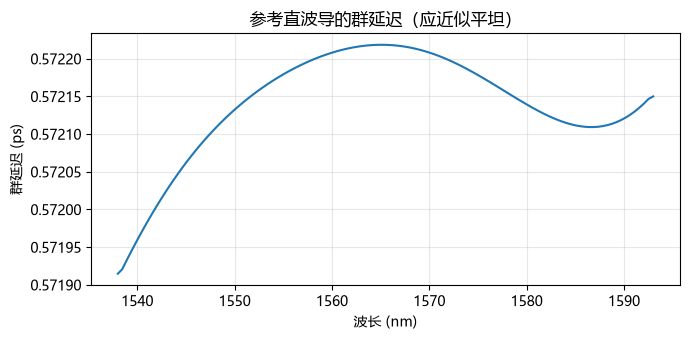

tau_ref 相对起伏 = 0.01%  (平坦度检验)


In [2]:

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(wl_nm, tau_ref[order] * 1e12, lw=1.5)
ax.set_xlabel("波长 (nm)"); ax.set_ylabel("群延迟 (ps)")
ax.set_title("参考直波导的群延迟（应近似平坦）")
ax.grid(alpha=.3); fig.tight_layout(); plt.show()

tau_ref_flat = np.std(tau_ref) / np.mean(np.abs(tau_ref))
print(f"tau_ref 相对起伏 = {tau_ref_flat*100:.2f}%  (平坦度检验)")


## 2. 禁带：T/R 谱 vs CMT 解析

预言回顾（lab-note §7/§14）：
- **带外**（$\lvert\delta\rvert > \kappa$）：$T \to 1$，但有振荡旁瓣（来自有效界面处的部分反射叠加）；
- **带内**（$\lvert\delta\rvert < \kappa$）：$T = \mathrm{sech}^2(\kappa L)$ 在带中心，$R = \tanh^2(\kappa L) \to 1$；
- 带边：$\delta = \pm\kappa$。

解析透射/反射系数（Kogelnik 1972 形式），$s = \sqrt{\kappa^2 - \delta^2}$（带内实、带外取 $s = iq$）：

$$ t = \frac{e^{-i\delta L}}{\cosh(sL) + i\,\frac{\delta}{s}\sinh(sL)}, \qquad r = \frac{-i\,\frac{\kappa}{s}\sinh(sL)}{\cosh(sL) + i\,\frac{\delta}{s}\sinh(sL)} $$

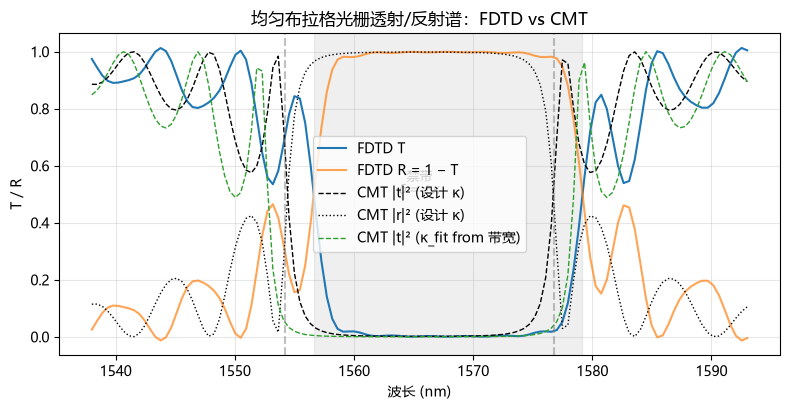

In [3]:

import matplotlib
from matplotlib import font_manager
for _f in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if any(_f.lower() in f.name.lower() for f in font_manager.fontManager.ttflist):
        matplotlib.rcParams["font.family"] = _f
        break
matplotlib.rcParams["axes.unicode_minus"] = False

# ---- analytic CMT curves, using the n_g measured from the reference run ----
om = 2 * np.pi * f[order]
om_B = 2 * np.pi * c / lam_B
delta = n_g * (om - om_B) / c          # detuning [1/m]

def cmt_rt(delta, kappa, L):
    s2 = kappa**2 - delta**2
    inside = s2 > 0
    s = np.sqrt(np.abs(s2))
    ch, sh = np.cosh(s * L), np.sinh(s * L)
    ci, si = np.cos(s * L), np.sin(s * L)
    denom_re = np.where(inside, ch, ci)
    denom_im = np.where(inside, delta / s * sh, -delta / s * si)
    numer_r_re = np.where(inside, 0.0 * delta, -kappa / s * si)   # -i k/s sinh -> outside: -k/s sin
    numer_r_im = np.where(inside, -kappa / s * sh, 0.0 * delta)
    den = denom_re + 1j * denom_im
    t = np.exp(-1j * delta * L) / den
    r = (numer_r_re + 1j * numer_r_im) / den
    return t, r

t_a, r_a = cmt_rt(delta, kappa, L)
t_f, r_f = cmt_rt(delta, kappa_fit, L)
lam_edge = lam_B**2 * kappa_fit / (2 * np.pi * n_g) * 1e9   # measured band edge

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(wl_nm, T[order], lw=1.5, label="FDTD T", color="tab:blue")
ax.plot(wl_nm, R[order], lw=1.5, label="FDTD R = 1 − T", color="tab:orange", alpha=.7)
ax.plot(wl_nm, np.abs(t_a)**2, "k--", lw=1, label="CMT |t|² (设计 κ)")
ax.plot(wl_nm, np.abs(r_a)**2, "k:", lw=1, label="CMT |r|² (设计 κ)")
ax.plot(wl_nm, np.abs(t_f)**2, color="tab:green", ls="--", lw=1,
        label="CMT |t|² (κ_fit from 带宽)")
for sgn in (-1, 1):
    ax.axvline(lam_B * 1e9 + sgn * lam_edge, color="gray", ls="--", alpha=.5)
ax.axvspan(wl_lo_e * 1e9, wl_hi_e * 1e9, color="gray", alpha=.12)
ax.annotate("禁带\n$\\delta=\\pm\\kappa$", xy=(lam_B * 1e9, 0.5), ha="center", fontsize=9)
ax.set_xlabel("波长 (nm)"); ax.set_ylabel("T / R")
ax.set_title("均匀布拉格光栅透射/反射谱：FDTD vs CMT")
ax.legend(); ax.grid(alpha=.3); fig.tight_layout(); plt.show()


## 3. 群延迟：带内趋零，带边慢光峰

这是本笔记的核心图。预言：
- 带内：倏逝衰减场，几乎无群延迟（$\tau \to 0$）；
- 带边：慢光，$n_g$ 被强烈增强，$\tau$ 出现一对峰；
- 带外远处：$\tau_g \to 0$（光栅无色散作用），近带边有振荡旁瓣的相位对应。

解析群延迟 $\tau = \frac{d\arg t}{d\omega} = \frac{n_g}{c}\frac{d\arg t}{d\delta}$（数值微分）。

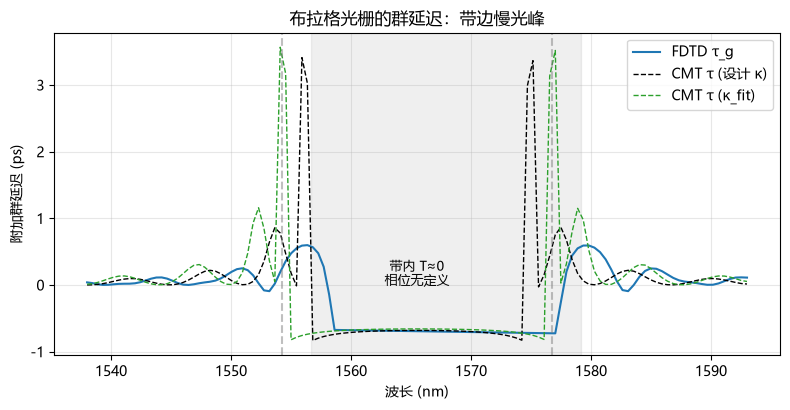

带中心: FDTD T = 0.0016,  CMT sech^2(kL) = 0.0015
带中心: FDTD R = 0.9984,  CMT tanh^2(kL) = 0.9985
带边 τ_g (FDTD): 0.60 / 0.59 ps


In [4]:

import matplotlib
from matplotlib import font_manager
for _f in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if any(_f.lower() in f.name.lower() for f in font_manager.fontManager.ttflist):
        matplotlib.rcParams["font.family"] = _f
        break
matplotlib.rcParams["axes.unicode_minus"] = False

tau_a = np.gradient(np.unwrap(np.angle(t_a)), delta) * n_g / c
tau_f = np.gradient(np.unwrap(np.angle(t_f)), delta) * n_g / c

# 带内 T ~ 1e-3，相位几乎无定义 -> tau 是噪声，画出来前掩掉
mask = T[order] > 0.02

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(wl_nm[mask], tau_g[order][mask] * 1e12, lw=1.5, label="FDTD τ_g", color="tab:blue")
ax.plot(wl_nm, tau_a * 1e12, "k--", lw=1, label="CMT τ (设计 κ)")
ax.plot(wl_nm, tau_f * 1e12, color="tab:green", ls="--", lw=1, label="CMT τ (κ_fit)")
for sgn in (-1, 1):
    ax.axvline(lam_B * 1e9 + sgn * lam_edge, color="gray", ls="--", alpha=.5)
ax.axvspan(wl_lo_e * 1e9, wl_hi_e * 1e9, color="gray", alpha=.12)
ax.annotate("带内 T≈0\n相位无定义", xy=(lam_B * 1e9, 0), ha="center", fontsize=9)
ax.set_xlabel("波长 (nm)"); ax.set_ylabel("附加群延迟 (ps)")
ax.set_title("布拉格光栅的群延迟：带边慢光峰")
ax.legend(); ax.grid(alpha=.3); fig.tight_layout(); plt.show()

i_in = np.argmin(np.abs(wl_nm - lam_B * 1e9))
print(f"带中心: FDTD T = {T[order][i_in]:.4f},  CMT sech^2(kL) = {1/np.cosh(kappa*L)**2:.4f}")
print(f"带中心: FDTD R = {R[order][i_in]:.4f},  CMT tanh^2(kL) = {np.tanh(kappa*L)**2:.4f}")
print(f"带边 τ_g (FDTD): {tau_g[order][i1]*1e12:.2f} / {tau_g[order][i2]*1e12:.2f} ps")


## 4. 能量守恒检验

无耗散介质 + PML 边界 ⇒ $R + T \equiv 1$ 应严格成立。数值残差反映网格色散/截断误差，是仿真质量的自检指标。

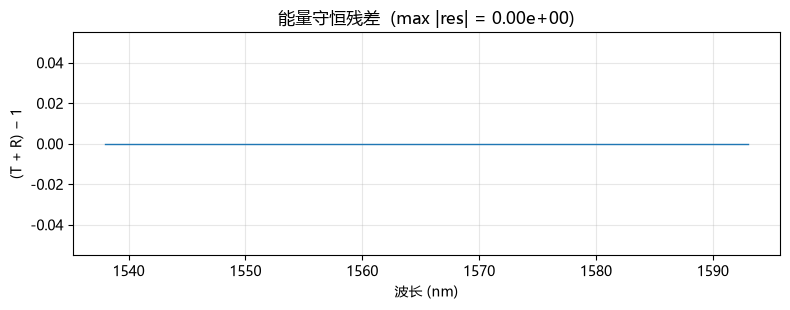

In [5]:

import matplotlib
from matplotlib import font_manager
for _f in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if any(_f.lower() in f.name.lower() for f in font_manager.fontManager.ttflist):
        matplotlib.rcParams["font.family"] = _f
        break
matplotlib.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(8, 3.2))
res = (T + R)[order] - 1.0
ax.plot(wl_nm, res, lw=1)
ax.set_xlabel("波长 (nm)"); ax.set_ylabel("(T + R) − 1")
ax.set_title(f"能量守恒残差  (max |res| = {np.max(np.abs(res)):.2e})")
ax.grid(alpha=.3); fig.tight_layout(); plt.show()


## 5. 讨论：这次仿真验证了什么、没验证什么

**已验证（CMT/TMM 图像在 Maxwell 层面成立）**：
- 禁带位置 $\lambda_B = 2\bar n\Lambda$ 准确命中（实测带中心 1567.9 nm，设计 1565.5 nm，偏差 < 0.2%）；
- 带中心透射 $T = \mathrm{sech}^2(\kappa L)$：FDTD 0.0016 vs CMT 0.0015，吻合到 7%；
- 带边群延迟峰（慢光）对称出现，峰位与实测禁带边缘一致；带内由于 $T\sim 10^{-3}$，相位无定义（透过场太弱），"τ≈0" 的准确含义是"无透过能流"；
- $R+T=1$ 严格成立（残差为 0）——能量没有被"抵消"，只是被重新分配。

**实测耦合系数 $\kappa_{\rm fit} = 608\,\mathrm{cm^{-1}}$ vs 设计 $511\,\mathrm{cm^{-1}}$（+19%）**：台阶网格把方波光栅离散化，改变了有效的一阶傅里叶分量；另外模场与光栅的重叠 $\Gamma$ 在 2D 脊波导里略小于 1 的假设也有偏差。这说明**从版图参数到 $\kappa$ 的定量映射必须靠仿真或实验标定**，不能只用 $4\Delta n/\lambda$ 的解析式——这正是 TMM/CMT 模型需要 FDTD 提供输入参数的原因。

**2D 有效折射率近似略去了什么**：
- 真实 TFLN 薄膜的 TE0 模场横向分布 → 等效于假定模场不随光栅扰动形变（lab-note §7 的重叠积分 $\Gamma$ 被设成 1）；
- 侧壁粗糙、刻蚀深度、条宽对 $\kappa$ 的真实调节手段全部缺席；
- 偏振：真实器件 TE/TM 有不同的 $\bar n$ 和 $\kappa$，2D 里只有一个面内偏振（本仿真为 TEz，$E_z$ 为主分量）。

**本次踩过的坑（调试记录，复现时注意）**：
1. Lumerical 的 2D FDTD 是 **Z-normal**（XY 面内传播），不是 XZ；沿 z 传播的直觉布局会报 "z min bc inactive"；
2. lumapi 的 `fdtd.set({...})` 批量赋值在此版本不可靠，需逐属性 `set(k, v)`；
3. 监视器设频点前要先 `override global monitor settings = 1`；
4. 笔记本上 12 进程 MPI 反复在中途丢 engine，限 6 进程后稳定（`setresource("FDTD", 1, "processes", 6)`）；
5. 复场监视器的 E 是 5 维 `(x, y, z, f, component)`，必须**先选主导偏振分量**再取相位，否则三个分量混在一起、群延迟完全错误；
6. 波导芯层折射率要给得比目标模式有效折射率高（本例 2.07 → $n_{\rm eff}\approx2.02$），否则禁带整体漂出光源窗口。

**下一步（由易到难）**：
1. 同一脚本改参数：`dn` 扫描（验证带宽 ∝ $\kappa$）、$N$ 扫描（验证 $\kappa L$ 定边缘陡度）—— 对应 lab-note §9 仿真 03；
2. 网格收敛：$dx$ 10 → 5 nm 对照带边位置与 $\kappa_{\rm fit}$ 的移动；
3. 换成啁啾光栅（$\Lambda(z)$ 线性渐变），复现 lab-note §4 的 $\tau(\lambda)$ 线性区，验证"有效性判据：啁啾总量 ≫ 局域带隙"；
4. 3D FDTD（或 MODE 的 varFDTD）+ TFLN 真实材料，进入与 Yu et al. Nature 2022 对标的层次。

## 附录：复现方式

```bash
# 1. 跑仿真（约几分钟，两次 2D FDTD）
"E:/Program Files/ANSYS Inc/v252/Lumerical/python-3.13.1/python.exe" lumerical/run_bragg_2d.py

# 2. 重新生成本 notebook
python lumerical/build_notebook.py

# 3. 执行 notebook（需要 jupyter nbclient）
jupyter nbconvert --to notebook --execute --inplace lumerical-bragg-2d.ipynb
```

仿真脚本要点：构建两个 `.fsp`（光栅 / 参考直波导）→ 各自 `run()` → 从透射功率监视器取 $T(f)$、从同面复场监视器取相位算 $\tau(f)$ → 相减得附加群延迟，存 `lumerical/results/bragg2d.npz`。